In [1]:
import httpx
import json
import requests
import geopandas as gpd
import shapely
import httpx
import cdrc
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt


In [25]:
# Set sheet name and CMA region
cma_sheet = "MVTZinc"
cma_region = "CEUS"

# Download the xlsx file and put it next to this file. This gets the sheet for the selected CMA
df = pd.read_excel("CriticalMAAS 12 Month Event TA1 Maps and TA2 Documents.xlsx",sheet_name=cma_sheet, engine='openpyxl')

# Set cma name output folder name to save found data
cma_name = "Lines_From_CDR" + "_" + cma_sheet + "_" + cma_region
cma_name = str(cma_name).lower()

In [3]:
# subset for georeferenced maps
df_reduced = df[df['NGMDB Georef']==True]

In [4]:
# get cog_ids
unique_cog_ids = df_reduced['COG ID'].dropna().unique()
cog_ids = [x for x in unique_cog_ids]
len(unique_cog_ids)

1362

In [5]:
# YOUR CDR TOKEN
cdr_token = "FILL IN TOKEN HERE"
client=cdrc.CDRClient(token=cdr_token)

In [6]:
# Read polygon and get corner coordinates
aoi = "../data/local/raw/boundaries/mvt/h3_mvt_reg_aoi.gpkg"

aoi_gdf = gpd.read_file(aoi).to_crs("EPSG:4326")
aoi_bbox = aoi_gdf.geometry.bounds

print(aoi_bbox)

        minx       miny       maxx       maxy
0 -97.814497  32.789377 -74.138156  44.576037


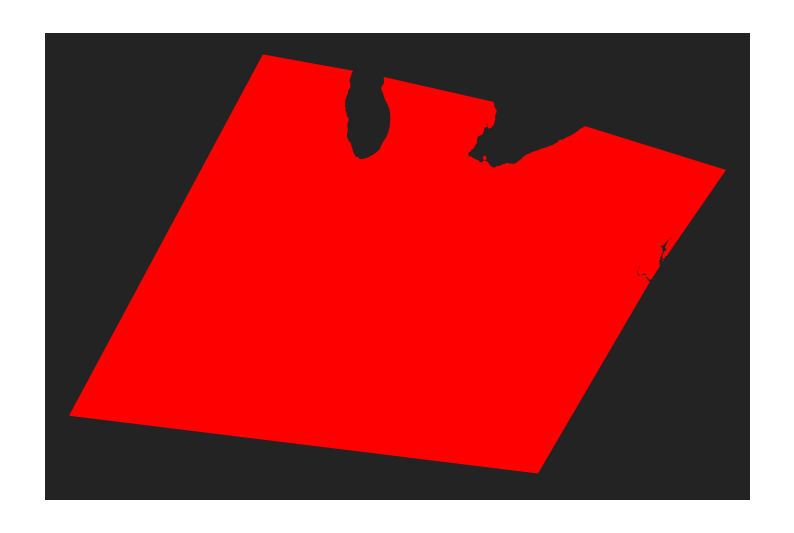

In [20]:
# Create a buffer around the AOI to reduce boundary effects from structures
aoi_buffer_gdf = aoi_gdf.copy()
aoi_buffer_gdf = aoi_buffer_gdf.to_crs("EPSG:3857")

aoi_buffer_bbox = aoi_buffer_gdf.geometry.bounds
aoi_buffer_bbox = shapely.geometry.box(*aoi_buffer_bbox.values.flatten())

buffer_m = 100000
aoi_buffer_bbox = aoi_buffer_bbox.buffer(buffer_m)

# Obtain new bounding box for the buffered AOI in the required CRS
aoi_buffer_gdf = gpd.GeoDataFrame(geometry=[aoi_buffer_bbox], crs="EPSG:3857").to_crs("EPSG:4326")
aoi_buffer_bbox = aoi_buffer_gdf.geometry.bounds

# Set bounding variable
aoi_bb_polygon = aoi_buffer_bbox

# Check the polyon and bounding box visually
fig, ax = plt.subplots(figsize=(10, 10))

rect = plt.Rectangle((aoi_bb_polygon.minx[0], aoi_bb_polygon.miny[0]),
                      aoi_bb_polygon.maxx[0] - aoi_bb_polygon.minx[0],
                      aoi_bb_polygon.maxy[0] - aoi_bb_polygon.miny[0],
                      edgecolor='none',
                      facecolor='#232323',
                      label='Bounding Box')

ax.add_patch(rect)
aoi_gdf.plot(ax=ax, color='red', edgecolor='red', label='AOI')
ax.set_frame_on(False)
ax.set_xticks([])
ax.set_yticks([])

plt.show()

In [21]:
# create a valid polygon from the cma. The final format should be. This is close I think but I would generate one from the shapefile. 
intersect_polygon = {
  "type": "Polygon",
  "coordinates": [
    [
      [
        aoi_bb_polygon.minx[0],
        aoi_bb_polygon.maxy[0]
      ],
      [
        aoi_bb_polygon.maxx[0],
        aoi_bb_polygon.maxy[0]
      ],
      [
        aoi_bb_polygon.maxx[0],
        aoi_bb_polygon.miny[0]
      ],
      [
        aoi_bb_polygon.minx[0],
        aoi_bb_polygon.miny[0]
      ],
      [
        aoi_bb_polygon.minx[0],
        aoi_bb_polygon.maxy[0]
      ],
    ]
  ]
}

In [22]:
client.build_cma_geopackages(
    cog_ids=cog_ids,
    feature_type="line",
    system_versions=[],
    validated=None,
    search_text="",
    intersect_polygon=intersect_polygon,
    cma_name=cma_name)

collecting records from cdr:  current amount 0 records
collecting records from cdr:  current amount 100000 records
collecting records from cdr:  current amount 148101 records
Finished collecting features
Finished getting legend items and features
Starting process for line extractions. 1790
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Starting process for line extractions. 3646
Feature is not georeferen

/Users/miyels/miniconda3/envs/cdr-ta4/lib/python3.12/site-packages/pyogrio/raw.py:709: RuntimeWarning: The filename extension should be 'gpkg' instead of '5__fault' to conform to the GPKG specification.
  ogr_write(


Starting process for line extractions. 544
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Starting process for line extractions. 2244
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in t

/Users/miyels/miniconda3/envs/cdr-ta4/lib/python3.12/site-packages/pyogrio/raw.py:709: RuntimeWarning: File ./FaultsFromCDR/projected/umn-usc-inferlink__0.0.5__fault has GPKG application_id, but non conformant file extension
  ogr_write(


Starting process for line extractions. 1389
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Starting process for line extractions. 737
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in t

...

Starting process for line extractions. 549
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Starting process for line extractions. 422
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Starting process for line extractions. 346
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Starting process for line extra

/Users/miyels/miniconda3/envs/cdr-ta4/lib/python3.12/site-packages/pyogrio/raw.py:709: RuntimeWarning: The filename extension should be 'gpkg' instead of '' to conform to the GPKG specification.
  ogr_write(
/Users/miyels/miniconda3/envs/cdr-ta4/lib/python3.12/site-packages/pyogrio/raw.py:709: RuntimeWarning: The filename extension should be 'gpkg' instead of '' to conform to the GPKG specification.
  ogr_write(


Starting process for line extractions. 820
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Starting process for line extractions. 2879
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in t

/Users/miyels/miniconda3/envs/cdr-ta4/lib/python3.12/site-packages/pyogrio/raw.py:709: RuntimeWarning: The filename extension should be 'gpkg' instead of '' to conform to the GPKG specification.
  ogr_write(
/Users/miyels/miniconda3/envs/cdr-ta4/lib/python3.12/site-packages/pyogrio/raw.py:709: RuntimeWarning: File ./FaultsFromCDR/projected/umn-usc-inferlink__0.0.5__inferredfault has GPKG application_id, but non conformant file extension
  ogr_write(


Starting process for line extractions. 1169
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Starting process for line extractions. 3673
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in the cdr
Feature is not georeferenced in 